In [ ]:
#Obesity prediction Kaggle
import seaborn as sns


In [3]:

datos = pd.read_csv("/content/drive/MyDrive/2025- enero-abr/03 arboles de decision/Obesity prediction.csv")

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [5]:
datos.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
datos.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


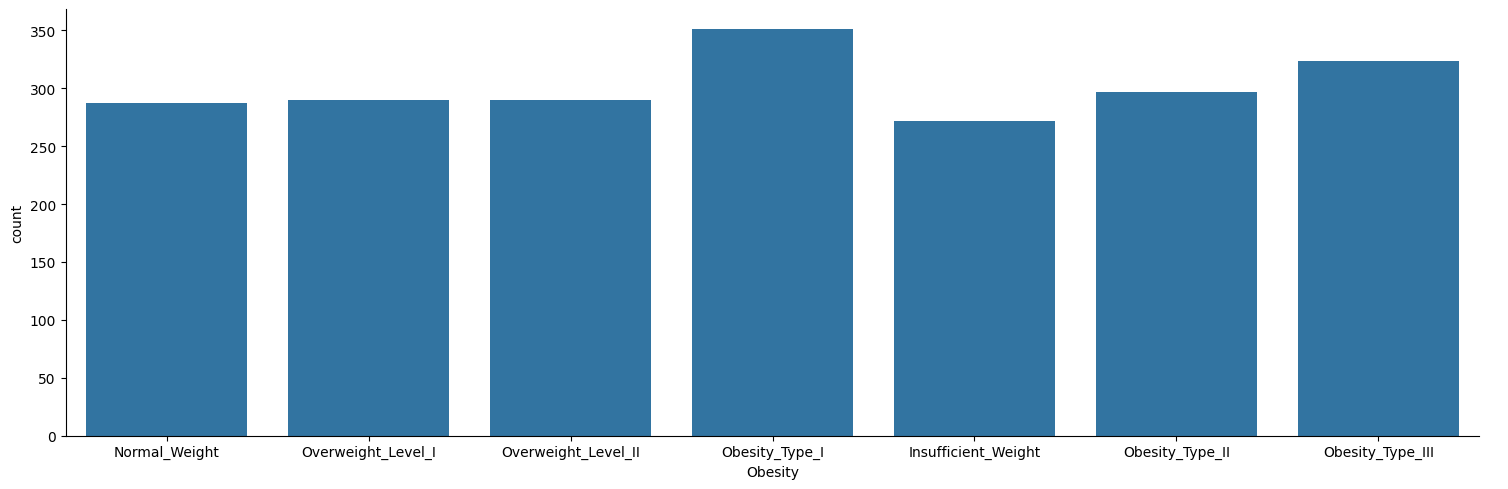

In [7]:
#grafica para contar cuantos hay en cada clase
import seaborn as sb

# Crear el gráfico countplot utilizando catplot para mayor control
sb.catplot(x="Obesity", data=datos,  kind="count", height=5, aspect=3)

In [8]:
def categorico_a_numerico_Genero(valor):
  if valor == "Male":
    return 0
  else:
    return 1

In [9]:
datos['Gender']=datos['Gender'].apply(categorico_a_numerico_Genero)
datos['Gender'].value_counts()

,count
Gender,
0,1068
1,1043


In [10]:
def categorico_a_numerico_SI_NO(valor):
  if valor == "no":
    return 0
  else:
    return 1

In [11]:

datos['family_history']=datos['family_history'].apply(categorico_a_numerico_SI_NO)
datos['family_history'].value_counts()

,count
family_history,
1,1726
0,385


In [12]:
datos['FAVC']=datos['FAVC'].apply(categorico_a_numerico_SI_NO)
datos['FAVC'].value_counts()

,count
FAVC,
1,1866
0,245


In [13]:
datos['SMOKE'].value_counts()

,count
SMOKE,
no,2067
yes,44


In [14]:
datos['SMOKE']=datos['SMOKE'].apply(categorico_a_numerico_SI_NO)
datos['SMOKE'].value_counts()

,count
SMOKE,
0,2067
1,44


In [15]:
datos['SCC']=datos['SCC'].apply(categorico_a_numerico_SI_NO)
datos['SCC'].value_counts()

,count
SCC,
0,2015
1,96


In [16]:
def categorico_a_numerico_VARIAS_OPC(valor):
  if valor == "Sometimes":
    return 0
  elif  valor == "Frequently":
    return 1
  elif  valor == "Always":
    return 2
  elif  valor == "no":
    return 3
  else:
    return

In [17]:
datos['CAEC']=datos['CAEC'].apply(categorico_a_numerico_VARIAS_OPC)
datos['CAEC'].value_counts()

,count
CAEC,
0,1765
1,242
2,53
3,51


In [18]:
datos['CALC']=datos['CALC'].apply(categorico_a_numerico_VARIAS_OPC)
datos['CALC'].value_counts()

,count
CALC,
0,1401
3,639
1,70
2,1


In [19]:
def categorico_a_numerico_VARIAS(valor):
  if valor == "Public_Transportation":
    return 0
  elif  valor == "Automobile":
    return 1
  elif  valor == "Walking":
    return 2
  elif  valor == "Motorbike":
    return 3
  elif  valor == "Bike":
    return 4
  else:
    return

In [20]:
datos['MTRANS']=datos['MTRANS'].apply(categorico_a_numerico_VARIAS)
datos['MTRANS'].value_counts()

,count
MTRANS,
0,1580
1,457
2,56
3,11
4,7


In [21]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   int64  
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   int64  
 5   FAVC            2111 non-null   int64  
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   int64  
 9   SMOKE           2111 non-null   int64  
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   int64  
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   int64  
 15  MTRANS          2111 non-null   int64  
 16  Obesity         2111 non-null   object 
dtypes: float64(8), int64(8), object(1

In [22]:
X = datos.drop(["Obesity"], axis=1)
y = datos["Obesity"]

In [23]:
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=.3)

In [24]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_ent, y_ent)
y_predicciones = modelo.predict(X_pru)

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, y_predicciones)

0.9242902208201893

In [26]:
datos['Obesity'].value_counts()


,count
Obesity,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [27]:
from sklearn.tree import DecisionTreeClassifier

resultados = []
for i in range(1,15):
  modelo = DecisionTreeClassifier(max_depth=i)
  modelo.fit(X_ent, y_ent)
  predicciones = modelo.predict(X_pru)
  exactitud = accuracy_score(y_pru, predicciones)
  print(f"Resultado para {i}: {exactitud}")
  resultados.append(exactitud)

Resultado para 1: 0.277602523659306
Resultado para 2: 0.5394321766561514
Resultado para 3: 0.6214511041009464
Resultado para 4: 0.777602523659306
Resultado para 5: 0.8201892744479495
Resultado para 6: 0.862776025236593
Resultado para 7: 0.8943217665615142
Resultado para 8: 0.9290220820189274
Resultado para 9: 0.919558359621451
Resultado para 10: 0.9290220820189274
Resultado para 11: 0.9242902208201893
Resultado para 12: 0.9258675078864353
Resultado para 13: 0.9305993690851735
Resultado para 14: 0.9290220820189274


<Axes: >

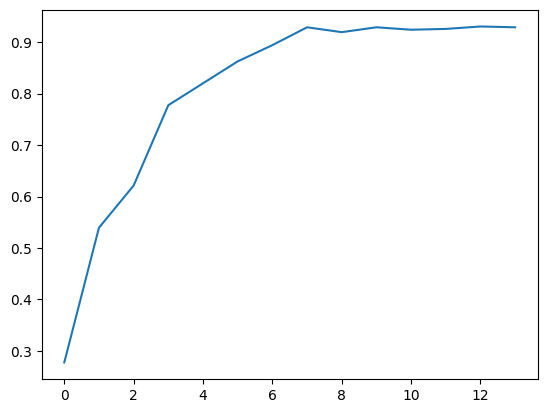

In [28]:
sb.lineplot(data=resultados)

In [29]:
modelo = DecisionTreeClassifier(max_depth=14)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(X_pru)
exactitud = accuracy_score(y_pru, predicciones)

In [30]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pru, predicciones)

array([[78, 10,  0,  0,  0,  0,  0],
       [ 7, 85,  0,  0,  0,  7,  0],
       [ 0,  0, 94,  3,  0,  0,  4],
       [ 0,  0,  1, 85,  0,  0,  1],
       [ 0,  0,  1,  0, 97,  0,  0],
       [ 0,  6,  0,  0,  0, 68,  4],
       [ 0,  0,  4,  0,  0,  0, 79]])

In [ ]:
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["PRED Insufficient_Weight", "PRED Normal_Weight","PRED Obesity_Type_I", "PRED Obesity_Type_II", "PRED Obesity_Type_III", "PRED Overweight_Level_I", "PRED Overweight_Level_II"], index=["REAL Insufficient_Weight", "REAL Normal_Weight","REAL Obesity_Type_I", "REAL Obesity_Type_II", "REAL Obesity_Type_III", "REAL Overweight_Level_I", "REAL Overweight_Level_II"])

,PRED Insufficient_Weight,PRED Normal_Weight,PRED Obesity_Type_I,PRED Obesity_Type_II,PRED Obesity_Type_III,PRED Overweight_Level_I,PRED Overweight_Level_II
REAL Insufficient_Weight,78,5,0,0,0,0,0
REAL Normal_Weight,5,76,0,0,0,7,1
REAL Obesity_Type_I,0,0,97,5,0,2,4
REAL Obesity_Type_II,0,0,0,90,0,0,1
REAL Obesity_Type_III,0,0,0,0,91,0,0
REAL Overweight_Level_I,0,7,0,0,0,72,2
REAL Overweight_Level_II,0,0,2,0,0,5,84


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(200, 80))
plot_tree(
    modelo,
    feature_names=X_ent.columns,
    class_names=["Insufficient_Weight", "Normal_Weight","Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III", "Overweight_Level_I", "Overweight_Level_II"],
    filled=True, label="none"
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
nueva_persona = [0, 55,1.60,64, 0, 0, 3.0,3.0,0,1,2.0, 0, 0, 3,1,1]
prediccion = modelo.predict([nueva_persona])
print(prediccion)

['Overweight_Level_I']


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
